In [1]:
import sys
import glob
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Camera selection, cross-platform.
#
# LINUX: every USB camera registers TWO /dev/video* nodes, a capture node and a
# metadata node that cannot stream (sysfs "index" = 0 and 1). Minor numbers are
# handed out in plug order, so they shift whenever you replug - the C270 was
# video4, the Dino-Lite came up as video5. Don't hardcode a number; match the
# device name instead. Substring, case-insensitive; None = first camera found.
#
# macOS: there is no /sys, so name matching is impossible here - AVFoundation
# exposes no device names through OpenCV. Its index order also does NOT match
# system_profiler's: USB cameras enumerate BEFORE the built-in FaceTime, so
# index 0 is normally the one you plugged in. Select by index on macOS.
MACOS = sys.platform == "darwin"
BACKEND = cv2.CAP_AVFOUNDATION if MACOS else cv2.CAP_V4L2

CAM_NAME = "c270"          # Linux only. "c270", "dino", "acer", or None


def list_cameras(max_index=3):
    """[(index, label)] for every camera that will actually stream.

    Linux reads real device names from sysfs. macOS has to probe each index and
    label it with the resolution it opens at, which costs ~1 s per index - so
    it is a thing you run to look, not something open_camera() calls.
    """
    if not MACOS:
        found = []
        for path in sorted(glob.glob("/sys/class/video4linux/video*")):
            try:
                with open(os.path.join(path, "index")) as f:
                    if int(f.read()) != 0:          # 1 = metadata node, can't stream
                        continue
                with open(os.path.join(path, "name")) as f:
                    found.append((int(os.path.basename(path)[5:]), f.read().strip()))
            except OSError:
                continue
        return found

    found = []
    for i in range(max_index):
        cap = cv2.VideoCapture(i, BACKEND)
        if cap.isOpened() and cap.read()[0]:
            found.append((i, "{0}x{1}".format(int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                                              int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))))
        cap.release()
    return found


_last_cap = []          # release stale handles: a cell interrupted before
                        # cap.release() leaves a VideoCapture bound to a node
                        # that may vanish on replug ("failed VIDIOC_REQBUFS:
                        # errno=19 No such device" from the old object).


def open_camera(name=None, index=None):
    """Open a camera. Linux: by name substring (default CAM_NAME). macOS: by
    index, defaulting to 0 (the USB camera); `name` is ignored there."""
    while _last_cap:
        _last_cap.pop().release()

    if index is None:
        if MACOS:
            index = 0                            # USB cams come first on AVFoundation
        else:
            cameras = list_cameras()
            want = CAM_NAME if name is None else name
            matches = [i for i, n in cameras
                       if want is None or want.lower() in n.lower()]
            if not matches:
                raise RuntimeError(
                    "no camera matching {0!r}; found {1}".format(want, cameras))
            index = matches[0]

    cap = cv2.VideoCapture(index, BACKEND)       # pinned: no silent FFMPEG fallback
    if cap.isOpened() and cap.read()[0]:
        _last_cap.append(cap)
        print("opened camera {0}: {1}x{2}".format(
            index, int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
            int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
        return cap
    cap.release()
    raise RuntimeError(
        "camera {0} won't stream (already open in another cell?); "
        "run list_cameras() to see what is available".format(index))

EXPOSURE = 150      # units of 100 us, so 15 ms. KEEP THIS <= 300: a frame at
                    # 30 fps is 33 ms, and an integration time longer than that
                    # cannot fit, so the camera silently halves to 15 fps. That
                    # is the usual reason a webcam "feels slow".


def lock_exposure(cap, exposure=EXPOSURE, gain=None):
    """Turn auto-exposure OFF and pin the integration time. Linux/V4L2 only.

    In a dim scene auto-exposure stretches integration until it exceeds the
    frame period and the rate halves -- measured on this C270 at 14.8 fps with
    scene brightness 77/255, and 29.7 fps at 111/255, same code both times.
    Locking it keeps the frame rate steady AND stops the mask drifting as the
    camera re-meters, which is what makes HSV_RANGES reproducible.

    Order matters: auto must go manual BEFORE the value, or the value is
    overwritten. V4L2 auto_exposure is 1 = manual, 3 = aperture priority, so 1
    is the setting that turns auto OFF. If the picture is too dark, raise gain
    rather than exposure -- exposure is what costs frame rate.
    """
    if MACOS:
        print("exposure lock unsupported on macOS: AVFoundation refuses every "
              "exposure/gain set(). Add light instead.")
        return False

    ok_auto = cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 1)
    if not ok_auto:                        # older OpenCV used a 0..1 scale here
        ok_auto = cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 0.25)
    ok_exp = cap.set(cv2.CAP_PROP_EXPOSURE, exposure)
    if gain is not None:
        cap.set(cv2.CAP_PROP_GAIN, gain)

    if exposure > 300:
        print("WARNING: exposure {0} = {1:.0f} ms exceeds the 33 ms frame "
              "period; expect 15 fps".format(exposure, exposure / 10))
    print("exposure lock: auto={0} value={1} -> reads back auto={2:g} exp={3:g}"
          .format("ok" if ok_auto else "REFUSED", "ok" if ok_exp else "REFUSED",
                  cap.get(cv2.CAP_PROP_AUTO_EXPOSURE), cap.get(cv2.CAP_PROP_EXPOSURE)))
    if not (ok_auto and ok_exp):
        print("  if refused, check the control names: newer kernels renamed "
              "exposure_auto -> auto_exposure and exposure_absolute -> "
              "exposure_time_absolute. Run:  v4l2-ctl -d /dev/video0 -l")
    return bool(ok_auto and ok_exp)

# 1: camera intrinsics calibration

In [2]:
# ChArUco board:
COLS, ROWS = 9, 6                       # 9 x 6; squares across, down
square_len = 0.016667                      # 16.667 mm squares, in metres
marker_len = 0.0125                     # 12.5 mm markers (must be < square)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
board = cv2.aruco.CharucoBoard((COLS, ROWS), square_len, marker_len, aruco_dict)

# page layout:
DPI = 600
PAGE_W_MM, PAGE_H_MM = 215.9, 279.4      # US Letter, portrait
mm2px = lambda mm: int(round(mm * DPI / 25.4))

# deriving the board size (px) from the square length and number of squares:
board_w_mm = COLS * square_len * 1000    # 150.0 mm
board_h_mm = ROWS * square_len * 1000    # 100.0 mm

board_w_px = mm2px(board_w_mm)
board_h_px = mm2px(board_h_mm)
assert board_w_px * ROWS == board_h_px * COLS, "pick a DPI where COLS divides the width in px"

page_w_px, page_h_px = mm2px(PAGE_W_MM), mm2px(PAGE_H_MM)
assert board_w_px <= page_w_px and board_h_px <= page_h_px, "board does not fit the page"

# generating the page image:
board_img = board.generateImage((board_w_px, board_h_px), marginSize=0)

page = np.full((page_h_px, page_w_px), 255, np.uint8)
x0, y0 = (page_w_px - board_w_px) // 2, (page_h_px - board_h_px) // 2
page[y0:y0 + board_h_px, x0:x0 + board_w_px] = board_img

Image.fromarray(page).save("charuco_9x6_letter.pdf", dpi=(DPI, DPI), format='PDF')

In [3]:
def calibrate_camera_intrinsic(image_filenames):
    detector = cv2.aruco.CharucoDetector(board)   # sub-pixel refines internally
    all_obj, all_img = [], []
    image_resolution = None

    for img_file in sorted(image_filenames):
        img = cv2.imread(img_file)
        if img is None:
            print("=> unreadable: {0}".format(img_file))
            continue
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        wh = img_gray.shape[:2][::-1]   # converts numpy (h, w) to (w, h)
        if image_resolution is None:
            image_resolution = wh
        elif wh != image_resolution:
            raise ValueError("{0}: size {1} != {2}".format(img_file, wh, image_resolution))

        corners, ids, _, _ = detector.detectBoard(img_gray)
        n = 0 if corners is None else len(corners)

        if n < 6:                       # too few (or none) to pose the board - skip
            continue
        
        objPoints, imgPoints = board.matchImagePoints(corners, ids)
        all_obj.append(objPoints)
        all_img.append(imgPoints)

    if len(all_obj) < 4:
        raise RuntimeError("only {0} usable views; aim for 20+".format(len(all_obj)))

    # Default 5-coefficient model (k1,k2,p1,p2,k3). CALIB_RATIONAL_MODEL adds 3
    # more radial terms but overfits unless many views reach the image border.
    (ret, camera_matrix, distortion_coefficients,
     rotation_vectors, translation_vectors) = cv2.calibrateCamera(
        all_obj, all_img, image_resolution, None, None)

    print('views used:', len(all_obj))
    print('ret (RMS reprojection, px):', ret)   # want < 0.5
    print('camera_matrix:', camera_matrix)
    print('distortion_coefficients:', distortion_coefficients.ravel())
    return True, camera_matrix, distortion_coefficients

def detect_calib_board(image_rgb, camera_matrix, dist_coeffs):
    output_img_rgb = image_rgb.copy()
    grey = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    detector = cv2.aruco.CharucoDetector(board)
    corners, chIds, mCorners, mIds = detector.detectBoard(grey)
    if corners is None or len(corners) < 4:
        print('Error: Could not identify the calibration board in the image!')
        return False, None, None, output_img_rgb

    # OpenCV 5 returns flat (N,2)/(N,) arrays; the drawing helpers want (N,1,*)
    if mIds is not None and len(mIds):
        cv2.aruco.drawDetectedMarkers(output_img_rgb, mCorners,
                                      np.asarray(mIds).reshape(-1, 1))
    cv2.aruco.drawDetectedCornersCharuco(output_img_rgb,
                                         np.asarray(corners).reshape(-1, 1, 2),
                                         np.asarray(chIds).reshape(-1, 1))

    objPoints, imgPoints = board.matchImagePoints(corners, chIds)
    ret_val, board_rvec_rdg, board_tvec = cv2.solvePnP(
        objPoints, imgPoints, camera_matrix, dist_coeffs)
    if not ret_val:
        print('Error: Could not identity the pose of the calibration board in the image!')
        return False, None, None, output_img_rgb

    print('Board rvec: ')
    print(board_rvec_rdg)
    print('Board tvec: ')
    print(board_tvec)

    length_of_axis = 0.05          # metres; ~1.7 squares, visible at 30 mm pitch
    cv2.drawFrameAxes(output_img_rgb, camera_matrix, dist_coeffs,
                      board_rvec_rdg, board_tvec, length_of_axis)
    plt.imshow(output_img_rgb)
    plt.show()
    return True, board_rvec_rdg, board_tvec, output_img_rgb

In [4]:
image_files = sorted(glob.glob("board_images/9x6/*.jpg"))
calibrated, camera_matrix, distortion_coefficients = calibrate_camera_intrinsic(image_files)

# Cache it so later cells (and other scripts) don't have to recalibrate:
np.savez("camera_intrinsics.npz",
         camera_matrix=camera_matrix, dist_coeffs=distortion_coefficients)

# load it with: d = np.load("camera_intrinsics.npz");
#              camera_matrix, distortion_coefficients = d["camera_matrix"], d["dist_coeffs"]

views used: 28
ret (RMS reprojection, px): 0.41149302608975674
camera_matrix: [[1.40878329e+03 0.00000000e+00 4.97553499e+02]
 [0.00000000e+00 1.40768507e+03 3.55701039e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion_coefficients: [ 0.13637615 -0.20408242  0.0045132   0.00309229 -0.52438292]


Board rvec: 
[[-0.25120552]
 [ 0.87129092]
 [ 2.74663753]]
Board tvec: 
[[0.07845677]
 [0.0257367 ]
 [0.32927154]]


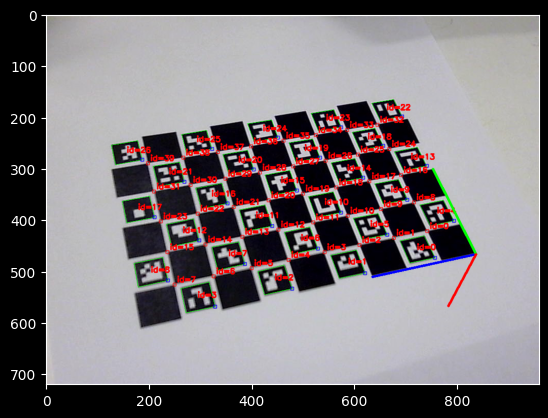

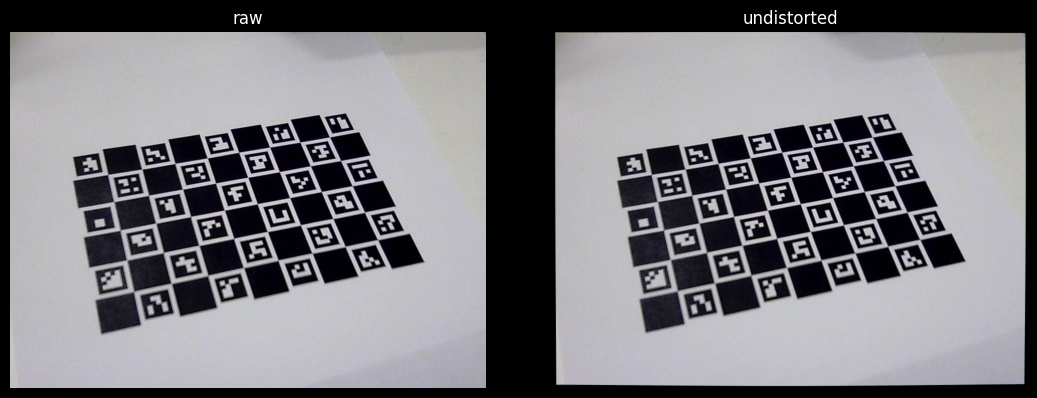

In [5]:
# Sanity check: board pose on one view + before/after undistortion
img_rgb = cv2.cvtColor(cv2.imread(image_files[1]), cv2.COLOR_BGR2RGB)
ok, rvec, tvec, drawn = detect_calib_board(img_rgb, camera_matrix, distortion_coefficients)

undistorted = cv2.undistort(img_rgb, camera_matrix, distortion_coefficients)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_rgb);      ax[0].set_title("raw");         ax[0].axis("off")
ax[1].imshow(undistorted);  ax[1].set_title("undistorted"); ax[1].axis("off")
plt.tight_layout(); plt.show()

In [6]:
# Colour segmentation in HSV.
#
# OpenCV hue is 0-179 (degrees / 2), S and V are 0-255. The S/V floors are what
# keep white walls and dark corners out of the mask - tune those before hue.
# Red straddles hue 0, so it needs two windows OR'd together; green and blue
# sit mid-range and need only one.
from turtle import width


HSV_RANGES = {
    "red":   [((  0, 120, 70), ( 10, 255, 255)),    # low side of the wrap
              ((170, 120, 70), (179, 255, 255))],   # high side
    "green": [(( 40,  80, 60), ( 85, 255, 255))],
    "blue":  [((100,  80, 60), (130, 255, 255))],
    "white":  [((0,  0, 40), (179, 255, 255))],
}

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))

def colour_mask(frame_bgr, colour):
    """Binary mask (0 / 255) of one named colour in HSV_RANGES."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = None
    for lo, hi in HSV_RANGES[colour]:
        m = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
        mask = m if mask is None else cv2.bitwise_or(mask, m)
        
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)  # -1 = all, FILLED
        
    mask = cv2.morphologyEx(filled, cv2.MORPH_OPEN, kernel)    # drop speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)   # fill pinholes
    
    mask = cv2.erode(mask, kernel, iterations=1)   # no dilate-back
    
    
    d = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    while True:
        grown = cv2.bitwise_and(cv2.dilate(mask, d), mask)  # dilate, then clip to mask
        if np.array_equal(grown, mask):
            break
        mask = grown
        
    return mask

def largest_blob(mask, min_area=200):
    """Biggest contour in a mask, or None. This is what you feed to the SVD pose cell."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    return cnt if cv2.contourArea(cnt) >= min_area else None



# 2: live ellipse-centre tracking

Camera -> HSV mask -> largest blob -> `cv2.fitEllipse` -> xy centre.
Reuses `open_camera` (cell 0) and `colour_mask` / `largest_blob` (cell 6).
Window shows the camera frame and the binary mask side by side.
Press **q** in the window to stop.

In [ ]:
# Live: camera -> HSV mask -> largest blob -> ellipse -> centre track. 'q' quits.
import time

cap = open_camera()                     # Linux: CAM_NAME. macOS: index 0.
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)     # else latency piles up in the driver queue
lock_exposure(cap)                      # no-op on macOS; see EXPOSURE in cell 0
print(f"streaming {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}"
      f"x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")

VIEW_SCALE = 0.5                        # two 1280-wide panels side by side is 2560

track, frames, t0 = [], 0, time.monotonic()
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames += 1
        mask = colour_mask(frame, "white")
        seg = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)   # binary panel, now drawable
        cnt = largest_blob(mask)
        if cnt is not None and len(cnt) >= 5:          # fitEllipse needs >= 5 points
            ellipse = cv2.fitEllipse(cnt)              # ((cx, cy), (w, h), angle)
            (cx, cy), _, _ = ellipse
            track.append((time.monotonic() - t0, cx, cy))
            cv2.drawContours(seg, [cnt], -1, (255, 0, 0), 1)   # what was actually fitted
            # Pass the tuple straight back. Its angle is paired with (w, h) in
            # ROTATED-BOX order, not major-first -- sorting the axes without
            # adding 90 deg would draw this rotated across the blob.
            for panel in (frame, seg):
                cv2.ellipse(panel, ellipse, (0, 255, 0), 2)
                cv2.circle(panel, (int(cx), int(cy)), 4, (0, 0, 255), -1)
        view = np.hstack((frame, seg))                 # camera | binary segmentation
        cv2.imshow("track", cv2.resize(view, None, fx=VIEW_SCALE, fy=VIEW_SCALE))
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:                        # must run: an interrupted cell otherwise keeps the
    cap.release()               # device, and the next open fails with
    cv2.destroyAllWindows()     # "VIDIOC_REQBUFS: errno=19 No such device"

dt = time.monotonic() - t0
print(f"{frames} frames in {dt:.1f} s = {frames / dt:.1f} fps; "
      f"{len(track)} with an ellipse ({100 * len(track) / max(frames, 1):.0f}%)")

In [ ]:
if not track:
    raise SystemExit("nothing tracked -- widen HSV_RANGES['white'] or lower min_area")

t, xs, ys = map(np.array, zip(*track))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(xs, ys, "-", lw=0.8)
ax1.set_aspect("equal")
ax1.invert_yaxis()                                  # image y grows downward
ax1.set_xlabel("x (px)"); ax1.set_ylabel("y (px)"); ax1.set_title("centre path")

ax2.plot(t, xs, lw=0.8, label="x")
ax2.plot(t, ys, lw=0.8, label="y")
ax2.set_xlabel("t (s)"); ax2.set_ylabel("px")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()